# Explorace datasetu

Notebook pro přehled a statistiky anotovaného datasetu — počty klipů, distribuce délky událostí, pokrytí dat.

In [1]:
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from config import OUTPUTS_DIR, LABELED_DIR

# Načtení anotací
with open(OUTPUTS_DIR / "annotations.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Celkový počet klipů: {len(data)}")
print(f"Klipy s wash událostí: {sum(1 for v in data.values() if v['events'])}")
print(f"Klipy bez aktivity: {sum(1 for v in data.values() if not v['events'])}")

Celkový počet klipů: 162
Klipy s wash událostí: 41
Klipy bez aktivity: 121


## Distribuce délky mytí rukou

Celkem GT událostí: 46
Průměrná délka mytí: 8.2 s
Medián: 8.0 s
Min: 1.4 s | Max: 19.8 s


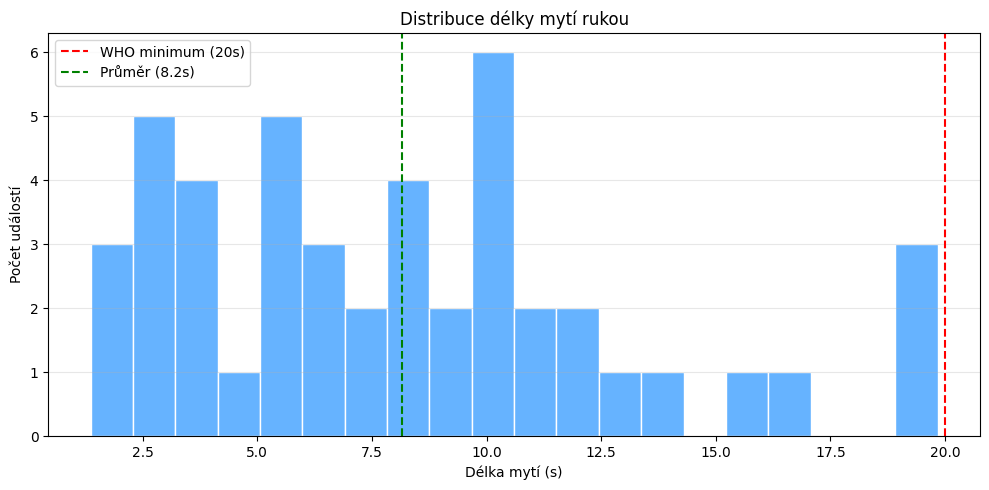

In [2]:
# Délky všech anotovaných wash událostí
durations = []
for clip, info in data.items():
    for ev in info["events"]:
        dur = ev["end_sec"] - ev["start_sec"]
        durations.append({"clip": clip, "start": ev["start_sec"], "end": ev["end_sec"], "duration": dur})

df = pd.DataFrame(durations)
print(f"Celkem GT událostí: {len(df)}")
print(f"Průměrná délka mytí: {df['duration'].mean():.1f} s")
print(f"Medián: {df['duration'].median():.1f} s")
print(f"Min: {df['duration'].min():.1f} s | Max: {df['duration'].max():.1f} s")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["duration"], bins=20, color="#66b3ff", edgecolor="white")
ax.axvline(20, color="red", linestyle="--", label="WHO minimum (20s)")
ax.axvline(df["duration"].mean(), color="green", linestyle="--", label=f"Průměr ({df['duration'].mean():.1f}s)")
ax.set_xlabel("Délka mytí (s)")
ax.set_ylabel("Počet událostí")
ax.set_title("Distribuce délky mytí rukou")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Přehled klipů a pokrytí

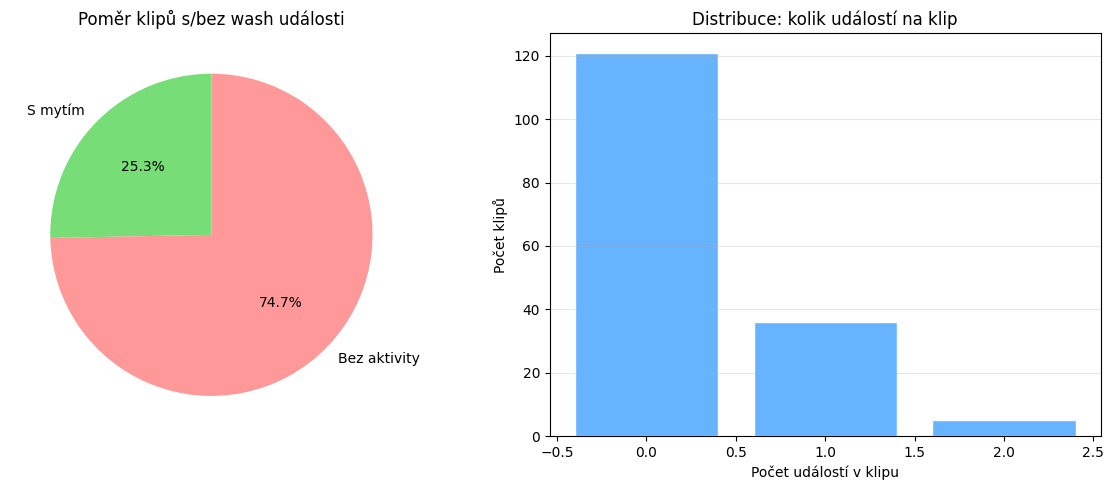

In [3]:
# Statistika: kolik klipů má 0, 1, 2+ událostí
event_counts = [len(v["events"]) for v in data.values()]
count_series = pd.Series(event_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart: klipy s/bez aktivity
with_events = sum(1 for c in event_counts if c > 0)
without_events = len(event_counts) - with_events
axes[0].pie([with_events, without_events], labels=["S mytím", "Bez aktivity"],
            autopct="%1.1f%%", colors=["#77dd77", "#ff9999"], startangle=90)
axes[0].set_title("Poměr klipů s/bez wash události")

# Bar chart: počet událostí per klip
count_dist = count_series.value_counts().sort_index()
axes[1].bar(count_dist.index, count_dist.values, color="#66b3ff", edgecolor="white")
axes[1].set_xlabel("Počet událostí v klipu")
axes[1].set_ylabel("Počet klipů")
axes[1].set_title("Distribuce: kolik událostí na klip")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Časové rozložení událostí v klipech

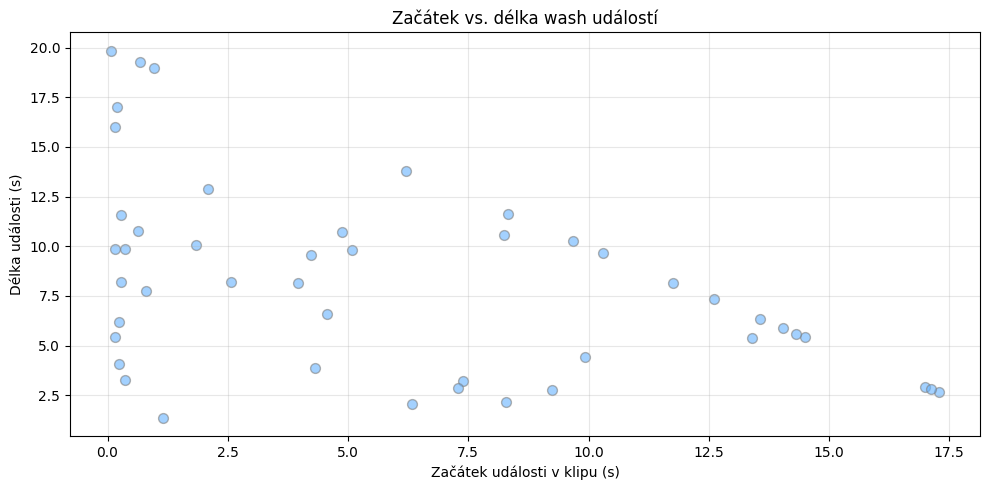

In [4]:
# Kdy v rámci klipu události začínají a končí
if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(df["start"], df["duration"], alpha=0.6, color="#66b3ff", edgecolor="gray", s=50)
    ax.set_xlabel("Začátek události v klipu (s)")
    ax.set_ylabel("Délka události (s)")
    ax.set_title("Začátek vs. délka wash událostí")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Žádné GT události k zobrazení.")